In [1]:
from pathlib import Path
import re
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from andria.backtest.engine import AlphaFactoryEngine
from andria.backtest.factors import RiskFactorModel
from andria.core.config import get_settings
from andria.core.logging import get_logger

logger = get_logger(__name__)
sns.set_theme(style="darkgrid", palette="muted")

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

In [2]:
def _canonical_quarter(raw_quarter: str | None) -> str | None:
    """Normalize EDGAR/SEC quarter labels to the regime-series key, e.g. 2014_Q2."""
    if raw_quarter is None:
        return None

    text = str(raw_quarter).upper()
    quarter_match = re.search(r"(\d{4})_?Q([1-4])", text)
    if quarter_match:
        return f"{quarter_match.group(1)}_Q{quarter_match.group(2)}"

    year_match = re.search(r"(\d{4})", text)
    if not year_match:
        return None

    month_to_quarter = {
        "JANUARY": 1,
        "FEBRUARY": 1,
        "MARCH": 1,
        "APRIL": 2,
        "MAY": 2,
        "JUNE": 2,
        "JULY": 3,
        "AUGUST": 3,
        "SEPTEMBER": 3,
        "OCTOBER": 4,
        "NOVEMBER": 4,
        "DECEMBER": 4,
    }
    for month, quarter in month_to_quarter.items():
        if month in text:
            return f"{year_match.group(1)}_Q{quarter}"

    return None

In [4]:
def _repair_unknown_regime_labels(signals: pl.DataFrame) -> pl.DataFrame:
    """Repair stale RACS artifacts whose regime join saved every row as Unknown."""
    if "regime_label" not in signals.columns:
        return signals

    known_regimes = signals.filter(pl.col("regime_label") != "Unknown").height
    if known_regimes > 0:
        return signals

    regime_path = PROJECT_ROOT / "artifacts" / "regime" / "regime_timeseries.parquet"
    if not regime_path.exists():
        print(f"WARNING: All signal regimes are Unknown and regime file is missing at {regime_path}.")
        return signals

    regime_map = (
        pl.read_parquet(regime_path)
        .with_columns(
            (
                pl.col("date").dt.year().cast(pl.Utf8)
                + "_Q"
                + pl.col("date").dt.quarter().cast(pl.Utf8)
            ).alias("quarter_key")
        )
        .select("quarter_key", "regime_label", "regime_prob")
    )
    repaired = (
        signals.drop("regime_label")
        .with_columns(
            pl.col("quarter")
            .map_elements(_canonical_quarter, return_dtype=pl.Utf8)
            .alias("quarter_key")
        )
        .join(regime_map, on="quarter_key", how="left")
        .with_columns(pl.col("regime_label").fill_null("Unknown"))
    )

    regime_weight = get_settings().signals.racs.regime_weight
    repaired = repaired.with_columns(
        (
            pl.col("conviction_raw")
            * (1.0 - pl.col("crowding_penalty"))
            * (
                1.0
                + pl.when(pl.col("regime_label").is_in(["Goldilocks", "Recovery"]))
                .then(regime_weight * pl.col("regime_prob").fill_null(0.0))
                .when(pl.col("regime_label") != "Unknown")
                .then(-regime_weight * pl.col("regime_prob").fill_null(0.0))
                .otherwise(0.0)
            )
        ).alias("regime_adjusted_racs")
    ).drop("quarter_key")

    repaired_count = repaired.filter(pl.col("regime_label") != "Unknown").height
    print(f"Repaired regime labels for {repaired_count}/{len(repaired)} signals from {regime_path}.")
    return repaired


## Load Artifacts

In [5]:
# Load the real signals generated in Phase 2
SIGNALS_PATH = PROJECT_ROOT / "artifacts" / "signals" / "racs_signals.parquet"
if SIGNALS_PATH.exists():
    signals_df = pl.read_parquet(SIGNALS_PATH)
    signals_df = _repair_unknown_regime_labels(signals_df)
    print(f"Loaded {len(signals_df)} real signals from Phase 2.")
else:
    print(f"WARNING: Real signals not found at {SIGNALS_PATH}. Falling back to small mock set.")
    signals_df = pl.DataFrame({
        "quarter": ["2015Q1", "2018Q2", "2020Q1", "2022Q3", "2024Q1"],
        "cusip": ["MOCK_AAPL"] * 5,
        "regime_adjusted_racs": [0.95, 0.88, 0.99, 0.85, 0.92],
        "regime_label": ["Goldilocks", "Recovery", "Recession_Fear", "Rate_Shock", "Goldilocks"]
    })

# Generate Mock Pricing for ALL unique CUSIPs in our signals
# We extend to 2027 to ensure coverage for the latest 2025/2026 signals
unique_cusips = signals_df["cusip"].unique().to_list()
dates = pd.date_range("2000-01-01", "2027-01-01", freq="B")
n_days = len(dates)
rng = np.random.default_rng(42)

print(f"Generating mock pricing for {len(unique_cusips)} tickers (2000-2027)...")
pricing_chunks = []
for ticker in unique_cusips:
    # GBM Parameters: 8-12% annual return, 20-40% annual vol
    mu = rng.uniform(0.08, 0.12) / 252
    sigma = rng.uniform(0.20, 0.40) / np.sqrt(252)
    daily_returns = rng.normal(mu, sigma, n_days)
    price_path = 100 * np.exp(np.cumsum(daily_returns))
    
    pricing_chunks.append(pl.DataFrame({
        "date": dates,
        "cusip": [ticker] * n_days,
        "close_adj": price_path,
        "close_price": price_path,
        "volume_30d_avg": 50_000_000.0,
        "volatility_30d": sigma # daily vol proxy
    }))

mock_pricing = pl.concat(pricing_chunks)
print(f"Mock pricing ready: {len(mock_pricing)} rows.")


Repaired regime labels for 86/86 signals from C:\Project\hedge funds\artifacts\regime\regime_timeseries.parquet.
Loaded 86 real signals from Phase 2.
Generating mock pricing for 19 tickers (2000-2027)...
Mock pricing ready: 133855 rows.


## Execute Backtest Engine

In [6]:
engine = AlphaFactoryEngine()
# Use every generated signal for this demonstration.
results = engine.run_backtest(signals_df, mock_pricing, top_n_decile=None)

ledger = results["ledger"]
metrics = results["metrics_by_regime"]

print(f"Final Trade Ledger: {len(ledger)} trades generated.")
print(f"Overall Sharpe: {results['overall_sharpe']:.2f}")
print(f"Survivorship Flags (Bankruptcies): {results['survivorship_flags']}")

2026-05-13 16:04:16 [info     ] backtest_started               pricing_rows=133855 signals=86
2026-05-13 16:04:16 [info     ] signal_filter_applied          selected=86 threshold=None top_n_decile=None total=86
2026-05-13 16:04:16 [info     ] backtest_completed             overall_sharpe=0.37
Final Trade Ledger: 86 trades generated.
Overall Sharpe: 0.37
Survivorship Flags (Bankruptcies): 0


In [7]:
ff_model = RiskFactorModel(start_date="2000-01-01")

# This will download real data from Ken French's library, compute cumulative log returns,
# and perform an OLS regression to extract true idiosyncratic alpha.
try:
    ledger = ff_model.orthogonalize(ledger)
    print("Risk Factor Neutralization Complete.")
    print("Ledger now contains 'idiosyncratic_alpha' column.")
except Exception as e:
    print(f"Skipping RFN due to network error: {e}")

2026-05-13 16:04:29 [info     ] fetching_fama_french_factors   start_date=2000-01-01
2026-05-13 16:04:35 [info     ] fama_french_processed          rows=6600
2026-05-13 16:04:35 [info     ] orthogonalization_pre_drop_stats entry_factor_nulls=0 exit_factor_nulls=0 net_fwd_return_nulls=0
2026-05-13 16:04:35 [info     ] risk_factor_regression_complete annualized_alpha_bps=1180.5 r_squared=0.062
Risk Factor Neutralization Complete.
Ledger now contains 'idiosyncratic_alpha' column.


## Regime-Conditional Performance

  regime_label n_obs mean_return    sharpe    max_dd raw_p_value  \
0   Rate_Shock    55    0.042356  0.579184 -0.436957    0.018122   
1   Goldilocks    16    0.001488  0.026095 -0.315321    0.479533   
2     Recovery    15   -0.006908 -0.098024 -0.414372    0.573914   

  fdr_significant  
0           False  
1           False  
2           False  


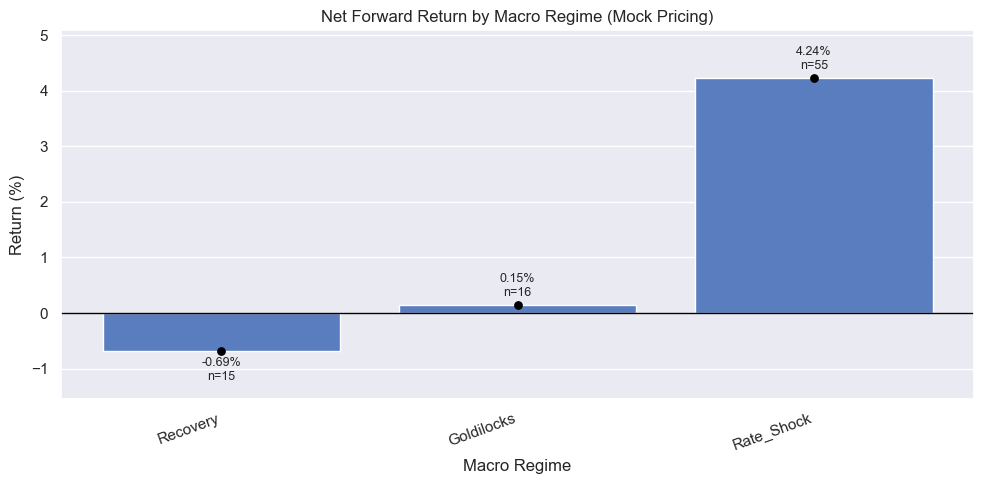

In [8]:
regime_df = pd.DataFrame(metrics).T.rename_axis("regime_label").reset_index()
regime_df = regime_df[["regime_label", "n_obs", "mean_return", "sharpe", "max_dd", "raw_p_value", "fdr_significant"]]
print(regime_df)

# Plot Mean Return by Regime
plot_df = regime_df.copy()
plot_df["mean_return_pct"] = plot_df["mean_return"].astype(float) * 100.0
regime_order = [
    regime
    for regime in ["Recovery", "Goldilocks", "Rate_Shock", "Recession_Fear", "Unknown"]
    if regime in set(plot_df["regime_label"])
]
plot_df = plot_df.set_index("regime_label").loc[regime_order].reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="regime_label", y="mean_return_pct", order=regime_order)
ax.axhline(0, color="black", linewidth=1)
ax.scatter(
    range(len(plot_df)),
    plot_df["mean_return_pct"],
    color="black",
    s=28,
    zorder=3,
)

max_abs = max(plot_df["mean_return_pct"].abs().max(), 0.25)
padding = max_abs * 0.2
ax.set_ylim(
    min(0.0, plot_df["mean_return_pct"].min() - padding),
    max(0.0, plot_df["mean_return_pct"].max() + padding),
)

for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
    height = patch.get_height()
    ax.annotate(
        f"{height:.2f}%\nn={int(row['n_obs'])}",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom" if height >= 0 else "top",
        xytext=(0, 4 if height >= 0 else -4),
        textcoords="offset points",
        fontsize=9,
    )
plt.title("Net Forward Return by Macro Regime (Mock Pricing)")
plt.xlabel("Macro Regime")
plt.ylabel("Return (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Out-of-Sample Validation (Train/Val/Test Split)

In [9]:
ledger = ledger.with_columns(
    pl.when(pl.col("exec_date").dt.year() <= 2018).then(pl.lit("Train"))
    .when(pl.col("exec_date").dt.year() <= 2023).then(pl.lit("Validate"))
    .otherwise(pl.lit("Test"))
    .alias("split")
)

split_metrics = ledger.group_by("split").agg(
    pl.col("net_fwd_return").mean().alias("mean_return"),
    pl.col("net_fwd_return").std().alias("std_return"),
    pl.len().alias("n_trades")
).to_pandas()

print(split_metrics)


      split  mean_return  std_return  n_trades
0     Train    -0.009047    0.107799        32
1      Test     0.001488    0.114069        16
2  Validate     0.066196    0.164667        38
